In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')    # Windows 내장
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')      # macOS
else:
    plt.rc('font', family='NanumGothic')      # Ubuntu: sudo apt install fonts-nanum

plt.rc('axes', unicode_minus=False)           # 마이너스 기호 깨짐 방지

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data   # 4특성 (꽃받침 길이/너비, 꽃잎 길이/너비)
y = iris.target # 정답 (0: setosa, 1: versicolor, 2: virginica)

In [9]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
print(np.unique(y))
print(iris.target_names)

[0 1 2]
['setosa' 'versicolor' 'virginica']


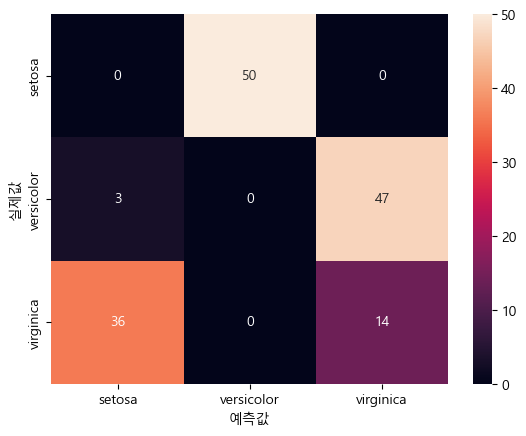

In [ ]:
km = KMeans(n_clusters=3, random_state=42)
km.fit(X)

cm = confusion_matrix(y, km.labels_)

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.xlabel('예측값')
plt.ylabel('실제값')

plt.show()

#### ARS (Adjusted Rand Score)
- 클러스터링 결과가 정답과 얼마나 일치하는가
- 비지도학습으로 나눈 군집을 정답 레이블과 비교하기 위해 사용 (단순 비교 시 레이블 번호만으로 확인하기 때문에 틀렸다고 인식)

```text
- 레이블 번호가 달라도 구조가 같으면 높은 점수
- 비지도학습처럼 정답 레이블이 있을 때만 사용 가능
- 실제 서비스에선 정답이 없으니, 주로 연구/실험에서 성능 검증용으로 사용
```

In [23]:
ars = adjusted_rand_score(y, km.labels_)
print(f"ARS (Adjusted Rand Score) : {ars:.4f}")

ARS (Adjusted Rand Score) : 0.7163


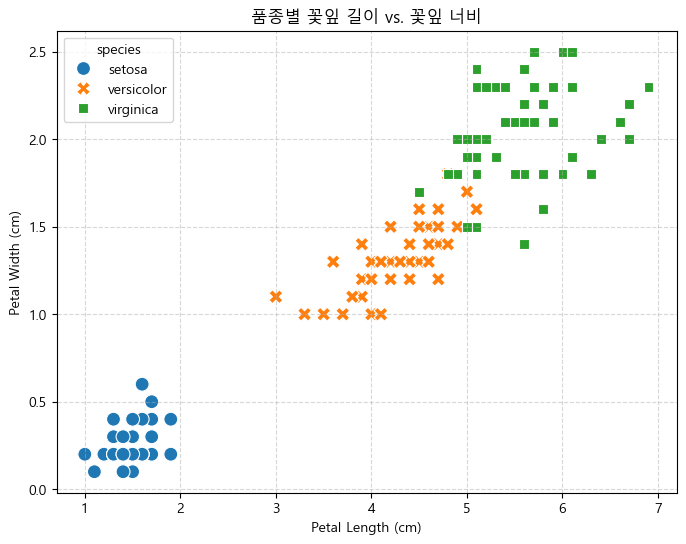

In [ ]:
# "setosa가 완벽 분리된 이유" 주석 한 문장
# 시각화했을 때, 다른 종의 꽃잎들과 달리 확연히 구분되는 모습을 보여줌 (압도적으로 작음)

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', 
                hue='species', style='species', s=100)

plt.title("품종별 꽃잎 길이 vs. 꽃잎 너비")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()